Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu

Cleaned shape: (48536, 14)
Missing after cleaning: 0

==================== FEDAVG ALL FEATURES | Target = Category ====================

==> Global Epoch 1/5 | ALL FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 2/5 | ALL FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 3/5 | ALL FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 4/5 | ALL FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 5/5 | ALL FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done
Accuracy: 0.5002
Classification Report:
                        precision    recal

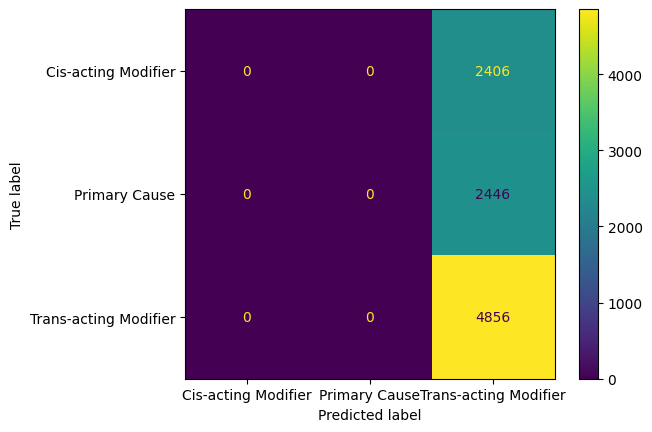

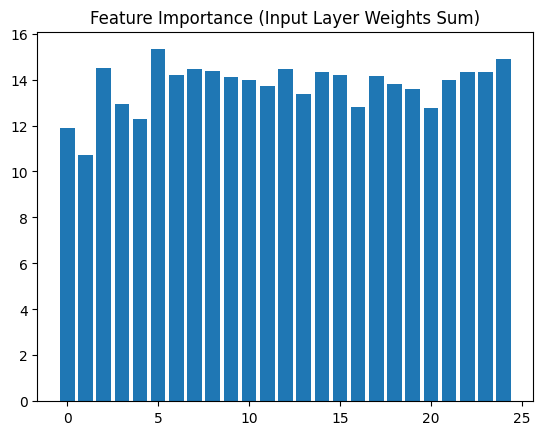


==================== FEDAVG ALL FEATURES | Target = Motor_Symptoms ====================

==> Global Epoch 1/5 | ALL FEATURES - Motor_Symptoms
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 2/5 | ALL FEATURES - Motor_Symptoms
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 3/5 | ALL FEATURES - Motor_Symptoms
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 4/5 | ALL FEATURES - Motor_Symptoms
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 5/5 | ALL FEATURES - Motor_Symptoms
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done
Accuracy: 0.3321
Classification Report:
               precision    recall  f1-score   support

        Mild       0.33      1.00      0.50      3224
    Moderate       0.00      0.00      0.00      3252
      Severe       0.00      0.00    

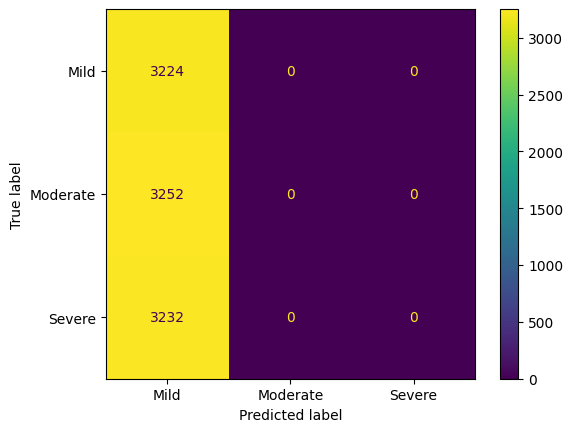

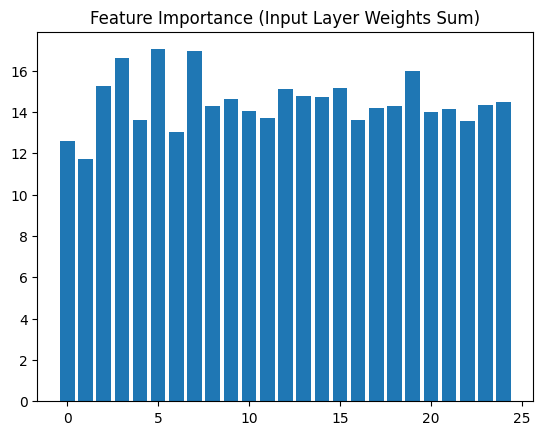


==================== FEDAVG ALL FEATURES | Target = Disease_Stage ====================

==> Global Epoch 1/5 | ALL FEATURES - Disease_Stage
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 2/5 | ALL FEATURES - Disease_Stage
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 3/5 | ALL FEATURES - Disease_Stage
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 4/5 | ALL FEATURES - Disease_Stage
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 5/5 | ALL FEATURES - Disease_Stage
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done
Accuracy: 0.2477
Classification Report:
                  precision    recall  f1-score   support

          Early       0.00      0.00      0.00      2407
           Late       0.25      1.00      0.40      2405
         Middle       0.00      0.

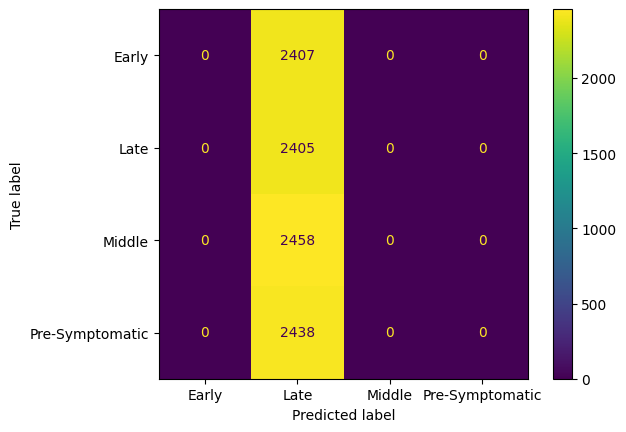

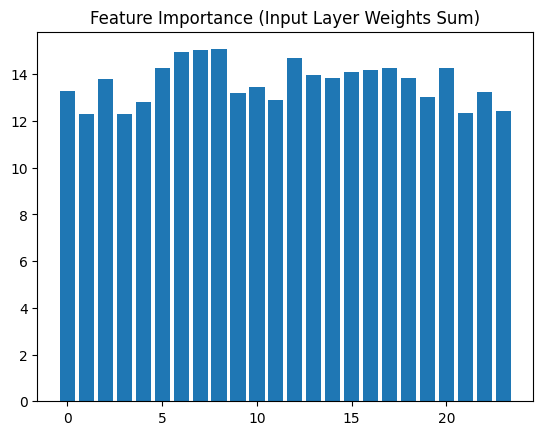


==================== FEDAVG NECESSARY FEATURES | Target = Category ====================

==> Global Epoch 1/5 | NECESSARY FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 2/5 | NECESSARY FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 3/5 | NECESSARY FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 4/5 | NECESSARY FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done

==> Global Epoch 5/5 | NECESSARY FEATURES - Category
  Client 1 done
  Client 2 done
  Client 3 done
  Client 4 done
  Client 5 done
Accuracy: 0.5002
Classification Report:
                        precision    recall  f1-score   support

  Cis-acting Modifier       0.00      0.00      0.00      2406
        Primary Cause       0.00      0.00      0.00      2446
Trans-acti

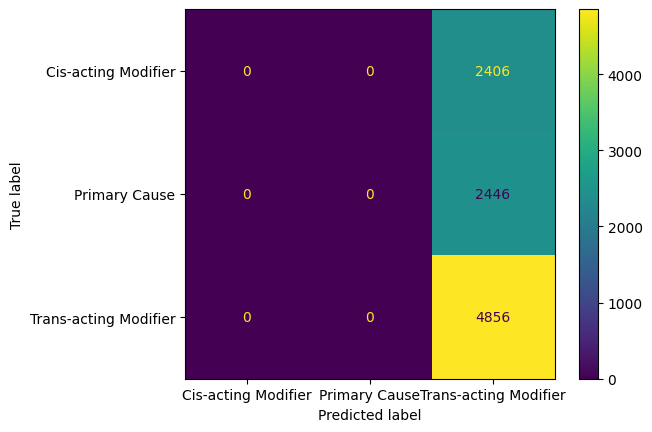

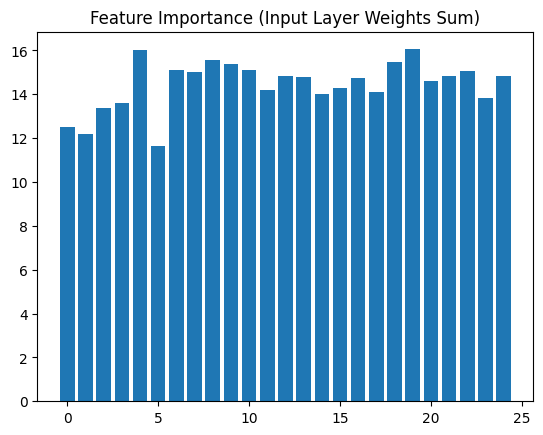

In [7]:
# =========================
# FULL FEDAVG PIPELINE (SimpleNN)
# =========================
!pip -q install -U torch scikit-learn matplotlib pandas numpy

import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset_Raw.csv"
NUM_CLIENTS = 5
LOCAL_EPOCHS = 3
GLOBAL_EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 0.01
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 0) LOAD + PREPROCESS
# =========================
df = pd.read_csv(DATA_PATH)

# Remove noisy / unnecessary columns
noise_cols = [
    "Patient_ID", "Random_Protein_Sequence", "Random_Gene_Sequence",
    "Gene/Factor", "Function", "Effect", "Chromosome_Location"
]
df = df.drop(columns=[c for c in noise_cols if c in df.columns], errors="ignore")

# Fill missing values
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].fillna(df[c].mode()[0])
for c in df.select_dtypes(include=np.number).columns:
    df[c] = df[c].fillna(df[c].median())
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str)

print("\nCleaned shape:", df.shape)
print("Missing after cleaning:", int(df.isnull().sum().sum()))

# =========================
# 1) HELPER FUNCTIONS
# =========================
class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def split_clients(X, y, num_clients=NUM_CLIENTS):
    size = len(X) // num_clients
    clients_data = []
    for i in range(num_clients):
        start = i*size
        end = (i+1)*size if i<num_clients-1 else len(X)
        clients_data.append((X[start:end], y[start:end]))
    return clients_data

def train_local(model, X, y, epochs=LOCAL_EPOCHS):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for _ in range(epochs):
        for i in range(0, len(X), BATCH_SIZE):
            xb = X[i:i+BATCH_SIZE]
            yb = y[i:i+BATCH_SIZE]
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def average_weights(weights_list):
    avg_w = deepcopy(weights_list[0])
    for key in avg_w.keys():
        for w in weights_list[1:]:
            avg_w[key] += w[key]
        avg_w[key] = torch.div(avg_w[key], len(weights_list))
    return avg_w

def evaluate_model(model, X_test, y_test, target_names):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == y_test).float().mean().item()
        print(f"Accuracy: {acc:.4f}")
        print("Classification Report:\n", classification_report(y_test.cpu(), preds.cpu(), target_names=target_names))
        cm = confusion_matrix(y_test.cpu(), preds.cpu())
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        disp.plot(values_format="d")
        plt.show()
        # Feature importance approximation: input weights magnitude
        with torch.no_grad():
            weights = model.net[0].weight.abs().sum(dim=0).cpu().numpy()
        plt.figure()
        plt.bar(range(len(weights)), weights)
        plt.title("Feature Importance (Input Layer Weights Sum)")
        plt.show()

# =========================
# 2) FEDAVG FUNCTION
# =========================
def fedavg_training(X_train_t, y_train_t, X_test_t, y_test_t, target_names, title=""):
    input_dim = X_train_t.shape[1]
    num_classes = len(target_names)
    clients = split_clients(X_train_t, y_train_t)
    global_model = SimpleNN(input_dim=input_dim, num_classes=num_classes).to(device)

    for g_epoch in range(GLOBAL_EPOCHS):
        local_weights = []
        print(f"\n==> Global Epoch {g_epoch+1}/{GLOBAL_EPOCHS} | {title}")
        for client_id, (Xc, yc) in enumerate(clients):
            model = deepcopy(global_model).to(device)
            Xc, yc = Xc.to(device), yc.to(device)
            w = train_local(model, Xc, yc)
            local_weights.append(w)
            print(f"  Client {client_id+1} done")
        global_weights = average_weights(local_weights)
        global_model.load_state_dict(global_weights)

    evaluate_model(global_model, X_test_t.to(device), y_test_t.to(device), target_names)

# =========================
# 3) TRAIN FEDAVG ON ALL FEATURES FOR 3 TARGETS
# =========================
targets_all = ["Category", "Motor_Symptoms", "Disease_Stage"]
for t in targets_all:
    if t in df.columns:
        print(f"\n==================== FEDAVG ALL FEATURES | Target = {t} ====================")
        X = pd.get_dummies(df.drop(columns=[t]), drop_first=False)

        # Convert all columns to numeric (robust)
        for c in X.columns:
            if X[c].dtype == "object":
                X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)

        le = LabelEncoder()
        y = le.fit_transform(df[t])
        target_names = le.classes_

        X_train, X_test, y_train, y_test = train_test_split(
            X.values.astype(np.float32), y, test_size=0.2, random_state=SEED, stratify=y
        )

        # Convert to tensors
        X_train_t = torch.tensor(X_train)
        X_test_t = torch.tensor(X_test)
        y_train_t = torch.tensor(y_train, dtype=torch.long)
        y_test_t = torch.tensor(y_test, dtype=torch.long)

        fedavg_training(X_train_t, y_train_t, X_test_t, y_test_t, target_names, title=f"ALL FEATURES - {t}")

# =========================
# 4) TRAIN FEDAVG ON NECESSARY FEATURES FOR CATEGORY
# =========================
necessary_features = [
    "Age","Sex","Family_History","HTT_CAG_Repeat_Length","Gene_Mutation_Type",
    "HTT_Gene_Expression_Level","Protein_Aggregation_Level","Brain_Volume_Loss",
    "Functional_Capacity","Cognitive_Decline","Chorea_Score","Motor_Symptoms","Disease_Stage"
]
necessary_features = [c for c in necessary_features if c in df.columns]

print(f"\n==================== FEDAVG NECESSARY FEATURES | Target = Category ====================")
X = pd.get_dummies(df[necessary_features], drop_first=False)

# Convert all columns to numeric
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)

le = LabelEncoder()
y = le.fit_transform(df["Category"])
target_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X.values.astype(np.float32), y, test_size=0.2, random_state=SEED, stratify=y
)

# Convert to tensors
X_train_t = torch.tensor(X_train)
X_test_t = torch.tensor(X_test)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

fedavg_training(X_train_t, y_train_t, X_test_t, y_test_t, target_names, title="NECESSARY FEATURES - Category")